# 读取数据

In [1]:
import  pandas as pd

REE_COLS = ['Ce', 'Dy', 'Er', 'Eu', 'Gd', 'Ho', 'Lu', 'Nd', 'Sm', 'Th', 'Tm', 'U', 'Yb']
# 1. 读取数据
file_path = r'G:\PythonProject\Bishe\data\raw\BiShe-total_data.CSV'
df = pd.read_csv(file_path)
df

,lat,lon,class,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
0,40.49,-121.51,magmatic,8.45,31.79,58.36,0.49,5.73,12.14,28.29,0.30,0.85,32.0,14.37,65.0,139.69
1,40.49,-121.51,magmatic,46.28,66.46,189.80,0.51,14.86,37.68,88.34,0.57,1.69,314.0,46.54,511.0,436.00
2,40.49,-121.51,magmatic,68.14,90.61,225.64,0.85,21.73,45.38,96.36,0.72,2.46,757.0,53.23,811.0,501.76
3,40.49,-121.51,magmatic,170.38,303.39,519.85,2.95,70.00,111.31,217.11,2.78,7.38,3497.0,119.34,2127.0,1104.03
4,40.49,-121.51,magmatic,18.54,41.55,87.39,0.27,7.40,16.25,42.14,0.14,0.81,67.0,21.60,137.0,199.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213,-25.17,-50.08,hydrothermal,1046.00,183.00,117.00,9.00,147.00,35.00,24.00,1046.00,242.00,6098.0,20.00,2046.0,162.00
7214,-25.17,-50.08,hydrothermal,1461.00,341.00,230.00,15.00,252.00,69.00,41.00,1257.00,339.00,7620.0,39.00,2035.0,298.00
7215,-25.17,-50.08,hydrothermal,1267.00,284.00,183.00,9.00,214.00,56.00,29.00,1274.00,291.00,3615.0,30.00,1386.0,217.00
7216,-25.17,-50.08,hydrothermal,1196.00,298.00,209.00,10.00,205.00,64.00,36.00,1384.00,343.00,3559.0,35.00,950.0,267.00


In [2]:
# 移除缺失标签的样本
df_labeled = df.dropna(subset=['class']).copy()
# 处理特征缺失值 - 使用中位数填充
for col in REE_COLS:
    df_labeled[col] = df_labeled[col].fillna(df_labeled[col].median())

In [3]:
df_labeled

,lat,lon,class,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
0,40.49,-121.51,magmatic,8.45,31.79,58.36,0.49,5.73,12.14,28.29,0.30,0.85,32.0,14.37,65.0,139.69
1,40.49,-121.51,magmatic,46.28,66.46,189.80,0.51,14.86,37.68,88.34,0.57,1.69,314.0,46.54,511.0,436.00
2,40.49,-121.51,magmatic,68.14,90.61,225.64,0.85,21.73,45.38,96.36,0.72,2.46,757.0,53.23,811.0,501.76
3,40.49,-121.51,magmatic,170.38,303.39,519.85,2.95,70.00,111.31,217.11,2.78,7.38,3497.0,119.34,2127.0,1104.03
4,40.49,-121.51,magmatic,18.54,41.55,87.39,0.27,7.40,16.25,42.14,0.14,0.81,67.0,21.60,137.0,199.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213,-25.17,-50.08,hydrothermal,1046.00,183.00,117.00,9.00,147.00,35.00,24.00,1046.00,242.00,6098.0,20.00,2046.0,162.00
7214,-25.17,-50.08,hydrothermal,1461.00,341.00,230.00,15.00,252.00,69.00,41.00,1257.00,339.00,7620.0,39.00,2035.0,298.00
7215,-25.17,-50.08,hydrothermal,1267.00,284.00,183.00,9.00,214.00,56.00,29.00,1274.00,291.00,3615.0,30.00,1386.0,217.00
7216,-25.17,-50.08,hydrothermal,1196.00,298.00,209.00,10.00,205.00,64.00,36.00,1384.00,343.00,3559.0,35.00,950.0,267.00


In [4]:
X = df_labeled.drop(['lat','lon','class'], axis=1)  # 特征

# 对数变换

In [5]:
import numpy as np
X_log = {}
for col in REE_COLS:
    X_log[f'{col}_log'] = np.log1p(X[col]).values
# 转换为DataFrame
X_features = pd.DataFrame(X_log)

# 处理无穷大和NaN
X_features = X_features.replace([np.inf, -np.inf], np.nan)
X_features = X_features.fillna(0)
X_features

D:\conda\envs\bishe\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Ce_log,Dy_log,Er_log,Eu_log,Gd_log,Ho_log,Lu_log,Nd_log,Sm_log,Th_log,Tm_log,U_log,Yb_log
0,2.246015,3.490124,4.083621,0.398776,1.906575,2.575661,3.377246,0.262364,0.615186,3.496508,2.732418,4.189655,4.946559
1,3.856087,4.211535,5.251226,0.412110,2.763800,3.655323,4.492449,0.451076,0.989541,5.752573,3.861571,6.238325,6.079933
2,4.236133,4.517540,5.423363,0.615186,3.123686,3.836868,4.578415,0.542324,1.241269,6.630683,3.993234,6.699500,6.220113
3,5.143883,5.718310,6.255462,1.373716,4.262680,4.721263,5.385000,1.329724,2.125848,8.159947,4.790321,7.662938,7.007628
4,2.972464,3.750680,4.481759,0.239017,2.128232,2.847812,3.764451,0.131028,0.593327,4.219508,3.117950,4.927254,5.302309
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,6.953684,5.214936,4.770685,2.302585,4.997212,3.583519,3.218876,6.953684,5.493061,8.715880,3.044522,7.624131,5.093750
6886,7.287561,5.834811,5.442418,2.772589,5.533389,4.248495,3.737670,7.137278,5.828946,8.938663,3.688879,7.618742,5.700444
6887,7.145196,5.652489,5.214936,2.302585,5.370638,4.043051,3.401197,7.150701,5.676754,8.193124,3.433987,7.234898,5.384495
6888,7.087574,5.700444,5.347108,2.397895,5.327876,4.174387,3.610918,7.233455,5.840642,8.177516,3.583519,6.857514,5.590987


# Boxplot

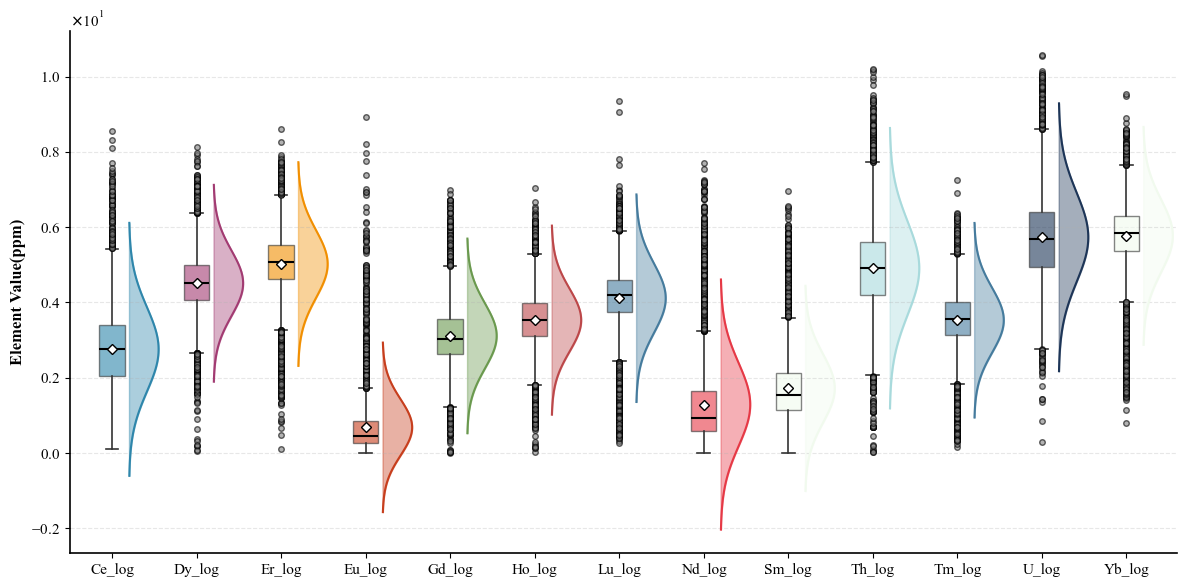

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import matplotlib.ticker as ticker

# 设置字体为 serif（学术常用，类似Times New Roman）
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2

# 从你的DataFrame提取数据
# data_list = [df[col].dropna().values for col in df.columns]
# group_names = df.columns.tolist()


# 从DataFrame提取数据
data_list = [X_features[col].dropna().values for col in X_features.columns]
group_names = X_features.columns.tolist()

# 配色方案
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749',
          '#457B9D', '#E63946', '#F1FAEE', '#A8DADC', '#457B9D', '#1D3557', '#F1FAEE']

# 创建图形
n_groups = len(data_list)
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制箱线图
positions = range(1, n_groups + 1)
bp = ax.boxplot(data_list,
               positions=positions,
               widths=0.3,
               patch_artist=True,
               showmeans=True,
               meanprops=dict(marker='D', markerfacecolor='white',
                             markeredgecolor='black', markersize=5),
               medianprops=dict(color='black', linewidth=1.5),
               whiskerprops=dict(linewidth=1.2, color='#333333'),
               capprops=dict(linewidth=1.2, color='#333333'),
               flierprops=dict(marker='o', markerfacecolor='gray',
                              markersize=4, alpha=0.6))

# 为箱子设置颜色
for patch, color in zip(bp['boxes'], colors[:n_groups]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('#333333')

# 绘制侧向正态曲线
for i, (d, color, pos) in enumerate(zip(data_list, colors[:n_groups], positions)):
    mu, std = np.mean(d), np.std(d)
    y_range = np.linspace(mu - 3*std, mu + 3*std, 100)
    pdf = stats.norm.pdf(y_range, mu, std)
    pdf_normalized = pdf / pdf.max() * 0.35

    x_curve = pos + 0.2 + pdf_normalized
    ax.fill_betweenx(y_range, pos + 0.2, x_curve, alpha=0.4, color=color)
    ax.plot(x_curve, y_range, color=color, linewidth=1.5)

# 设置坐标轴
ax.set_ylabel('Element Value(ppm)', fontsize=12, fontweight='bold')
# ax.set_title('Boxplot with Normal Distribution Curves', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(positions)
ax.set_xticklabels(group_names, rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 调整y轴刻度格式（使用科学计数法）
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# 调整x轴范围
ax.set_xlim(0.5, n_groups + 0.6)

plt.tight_layout()
plt.savefig('boxplot_improved.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

